# 01 Session features

One row per session, over the same seven day window as 00 (2026-09-14 to 2026-09-20), built on top of what 00 confirmed about silver: connect and closed pair up 1:1 for all 22,511 sessions, exactly one session crosses a day partition, and censoring is readable off the duration spike near 120000ms rather than off a reason field.

Three column groups:

1. Identifiers. `session`, `src_ip`, `connect_time`, plus the raw `client_version` / `client_kex` strings for reference.
2. Outcomes. `duration_sec`, `event_observed`, `command_count`. These never go into 02's feature set, since clustering on an axis and then finding the axis separates clusters is circular.
3. Features. Everything else: login behaviour, download behaviour, client fingerprint frequency, connection timing, repeat-visit count, and eventid pivot counts.

Writes the result to `/data/work/sessions/sessions.parquet`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from honeypot_analytics import db

con = db.connect()

# The same window as 00, for the same reason: silver grows a partition a day
# and these numbers go into the write-up.
WINDOW_FROM = "2026-09-14"
WINDOW_TO = "2026-09-20"

SILVER = (
    "(SELECT * FROM "
    + db.silver_events_source()
    + " WHERE year || '-' || month || '-' || day"
    + f" BETWEEN '{WINDOW_FROM}' AND '{WINDOW_TO}')"
)


def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 1. Skeleton and outcomes

One connect and one closed per session, joined on `session`. `duration_ms` is silver's actual column name, not `duration`.

In [2]:
base = q(f"""
    WITH connects AS (
        SELECT session, src_ip, "timestamp" AS connect_time
        FROM {SILVER}
        WHERE eventid = 'cowrie.session.connect'
    ),
    closes AS (
        SELECT session, duration_ms
        FROM {SILVER}
        WHERE eventid = 'cowrie.session.closed'
    )
    SELECT c.session, c.src_ip, c.connect_time, cl.duration_ms
    FROM connects c
    JOIN closes cl USING (session)
""")
assert base["session"].is_unique
base["duration_sec"] = base["duration_ms"] / 1000.0
base.shape

(22511, 5)

`event_observed`: 00 found a near-empty gap between roughly 100s and 119s (four sessions in the whole window), then 573 sessions packed into 120001ms and the few hundred milliseconds after it, then another gap before the long organic tail. That band is the honeypot's idle timeout, so anything landing in it is censored (the attacker did not choose to leave). Everything else, including the 0/1ms instant disconnects, counts as an observed hang-up rather than being dropped: those are real recorded lifetimes, just short ones, and dropping them would bias 03 away from whatever is causing them.

In [3]:
IDLE_TIMEOUT_LOW_MS = 119_000
IDLE_TIMEOUT_HIGH_MS = 121_000

base["event_observed"] = ~base["duration_ms"].between(
    IDLE_TIMEOUT_LOW_MS, IDLE_TIMEOUT_HIGH_MS
)
base["event_observed"].value_counts()

event_observed
True     21937
False      574
Name: count, dtype: int64

In [4]:
commands = q(f"""
    SELECT session, count(*) AS command_count
    FROM {SILVER}
    WHERE eventid = 'cowrie.command.input'
    GROUP BY 1
""")

sessions = base.merge(commands, on="session", how="left")
sessions["command_count"] = sessions["command_count"].fillna(0).astype(int)
sessions["command_count"].describe()

count    22511.000000
mean         0.768913
std          0.521245
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         18.000000
Name: command_count, dtype: float64

## 2. Login features

Attempts, success, and how many distinct credentials were tried. `password` is null for the handful of pubkey attempts in `login.failed`, which `count(DISTINCT ...)` already skips.

In [5]:
logins = q(f"""
    SELECT
        session,
        count(*) FILTER (WHERE eventid = 'cowrie.login.success') AS login_success_count,
        count(*) FILTER (WHERE eventid = 'cowrie.login.failed') AS login_failed_count,
        count(DISTINCT username) AS unique_usernames,
        count(DISTINCT password) AS unique_passwords
    FROM {SILVER}
    WHERE eventid IN ('cowrie.login.success', 'cowrie.login.failed')
    GROUP BY 1
""")

sessions = sessions.merge(logins, on="session", how="left")
for c in ["login_success_count", "login_failed_count", "unique_usernames", "unique_passwords"]:
    sessions[c] = sessions[c].fillna(0).astype(int)

sessions["login_attempts"] = sessions["login_success_count"] + sessions["login_failed_count"]
sessions["login_success"] = sessions["login_success_count"] > 0
sessions = sessions.drop(columns=["login_success_count", "login_failed_count"])
sessions[["login_attempts", "login_success", "unique_usernames", "unique_passwords"]].describe(include="all")

,login_attempts,login_success,unique_usernames,unique_passwords
count,22511.000000,22511,22511.000000,22511.000000
unique,NaN,2,NaN,NaN
top,NaN,True,NaN,NaN
freq,NaN,19679,NaN,NaN
mean,0.878948,NaN,0.878237,0.878193
std,0.328367,NaN,0.327019,0.327884
min,0.000000,NaN,0.000000,0.000000
25%,1.000000,NaN,1.000000,1.000000
50%,1.000000,NaN,1.000000,1.000000
75%,1.000000,NaN,1.000000,1.000000


## 3. Download features

The plan called for a unique URL count, but `cowrie.session.file_download` does not carry a `url` field in this silver. What it carries is `shasum` (the payload hash) and `destfile` (where it landed, e.g. `/home/oracle/.ssh/authorized_keys`), which points at authorized_keys injection rather than a wget-a-binary pattern. Using `shasum` as the unique-payload count in place of unique URLs.

In [6]:
downloads = q(f"""
    SELECT
        session,
        count(*) AS download_count,
        count(DISTINCT shasum) AS unique_payloads
    FROM {SILVER}
    WHERE eventid = 'cowrie.session.file_download'
    GROUP BY 1
""")

sessions = sessions.merge(downloads, on="session", how="left")
for c in ["download_count", "unique_payloads"]:
    sessions[c] = sessions[c].fillna(0).astype(int)
sessions[["download_count", "unique_payloads"]].describe()

,download_count,unique_payloads
count,22511.000000,22511.000000
mean,0.011328,0.011328
std,0.110753,0.110753
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,2.000000,2.000000


## 4. Client identity

`client.version` is the SSH banner string (125 distinct values, dominated by `SSH-2.0-Go`). For `client.kex`, the plan named the event but not a field: using `hassh`, the MD5 of the client's algorithm lists, since that is what it exists for, a single fingerprint per client implementation (60 distinct values here). Both are long-tailed enough that frequency encoding beats one-hot; the histogram/heatmap step below is where a top-N one-hot would get reconsidered if the frequency encoding turns out not to separate anything.

In [7]:
client_version = q(f"""
    SELECT session, version AS client_version
    FROM {SILVER}
    WHERE eventid = 'cowrie.client.version'
""")
client_kex = q(f"""
    SELECT session, hassh AS client_kex
    FROM {SILVER}
    WHERE eventid = 'cowrie.client.kex'
""")
assert not client_version["session"].duplicated().any()
assert not client_kex["session"].duplicated().any()

sessions = sessions.merge(client_version, on="session", how="left")
sessions = sessions.merge(client_kex, on="session", how="left")

version_freq = sessions["client_version"].value_counts(normalize=True)
kex_freq = sessions["client_kex"].value_counts(normalize=True)
sessions["client_version_freq"] = sessions["client_version"].map(version_freq).fillna(0.0)
sessions["client_kex_freq"] = sessions["client_kex"].map(kex_freq).fillna(0.0)
sessions[["client_version_freq", "client_kex_freq"]].describe()

,client_version_freq,client_kex_freq
count,22511.000000,22511.000000
mean,0.704440,0.402929
std,0.333155,0.297270
min,0.000000,0.000000
25%,0.864962,0.037613
50%,0.864962,0.645749
75%,0.864962,0.645749
max,0.864962,0.645749


## 5. Timing and repeat visits

Hour of day as sin/cos so midnight is not a cliff edge. Same-`src_ip` session count for the day, on the connect date, not the day partition column, since 00 already showed those agree here.

In [8]:
hour = sessions["connect_time"].dt.hour
sessions["connect_hour_sin"] = np.sin(2 * np.pi * hour / 24)
sessions["connect_hour_cos"] = np.cos(2 * np.pi * hour / 24)

connect_date = sessions["connect_time"].dt.date
sessions["src_ip_sessions_same_day"] = (
    sessions.groupby(["src_ip", connect_date])["session"].transform("count")
)
sessions[["connect_hour_sin", "connect_hour_cos", "src_ip_sessions_same_day"]].describe()

,connect_hour_sin,connect_hour_cos,src_ip_sessions_same_day
count,22511.000000,22511.000000,22511.000000
mean,-0.309680,-0.080177,785.239527
std,0.715979,0.620552,661.389654
min,-1.000000,-1.000000,1.000000
25%,-0.866025,-0.707107,22.000000
50%,-0.707107,-0.258819,1096.000000
75%,0.500000,0.500000,1437.000000
max,1.000000,1.000000,1437.000000


## 6. Eventid pivot counts

One count column per remaining eventid. `session.connect` and `session.closed` are excluded because they are exactly 1 for every session by construction, and `command.input` is excluded because it is `command_count`, an outcome.

In [9]:
excluded_eventids = {
    "cowrie.session.connect",
    "cowrie.session.closed",
    "cowrie.command.input",
}
eventids = [
    e for e in q(f"SELECT DISTINCT eventid FROM {SILVER}")["eventid"]
    if e not in excluded_eventids
]

in_list = ", ".join(f"'{e}'" for e in eventids)
long = q(f"""
    SELECT session, eventid, count(*) AS n
    FROM {SILVER}
    WHERE eventid IN ({in_list})
    GROUP BY 1, 2
""")
pivot = long.pivot(index="session", columns="eventid", values="n").fillna(0)
pivot.columns = [f"n_{c.replace('cowrie.', '').replace('.', '_')}" for c in pivot.columns]

sessions = sessions.merge(pivot, on="session", how="left")
for c in pivot.columns:
    sessions[c] = sessions[c].fillna(0).astype(int)
pivot.shape

(21120, 17)

## 7. Assemble

Column groups kept explicit so 02 knows which ones it is allowed to cluster on.

In [10]:
identifier_cols = ["session", "src_ip", "connect_time", "client_version", "client_kex"]
outcome_cols = ["duration_sec", "event_observed", "command_count"]
feature_cols = [c for c in sessions.columns if c not in identifier_cols + outcome_cols + ["duration_ms"]]

sessions = sessions[identifier_cols + outcome_cols + feature_cols]
print(sessions.shape)
sessions.dtypes

(22511, 36)


session                              object
src_ip                               object
connect_time                 datetime64[us]
client_version                       object
client_kex                           object
duration_sec                        float64
event_observed                         bool
command_count                         int64
unique_usernames                      int64
unique_passwords                      int64
login_attempts                        int64
login_success                          bool
download_count                        int64
unique_payloads                       int64
client_version_freq                 float64
client_kex_freq                     float64
connect_hour_sin                    float64
connect_hour_cos                    float64
src_ip_sessions_same_day              int64
n_client_fingerprint                  int64
n_client_kex                          int64
n_client_malformed_packet             int64
n_client_size                   

## 8. Distributions and redundancy

Material for dropping columns in 02, not a conclusion by itself. Near-zero-variance columns (the tiny eventid counts) and near-perfectly correlated pairs (e.g. `download_count` vs `unique_payloads`, or `n_log_closed` vs `n_session_params` vs `command_count`) are the ones to prune before clustering.

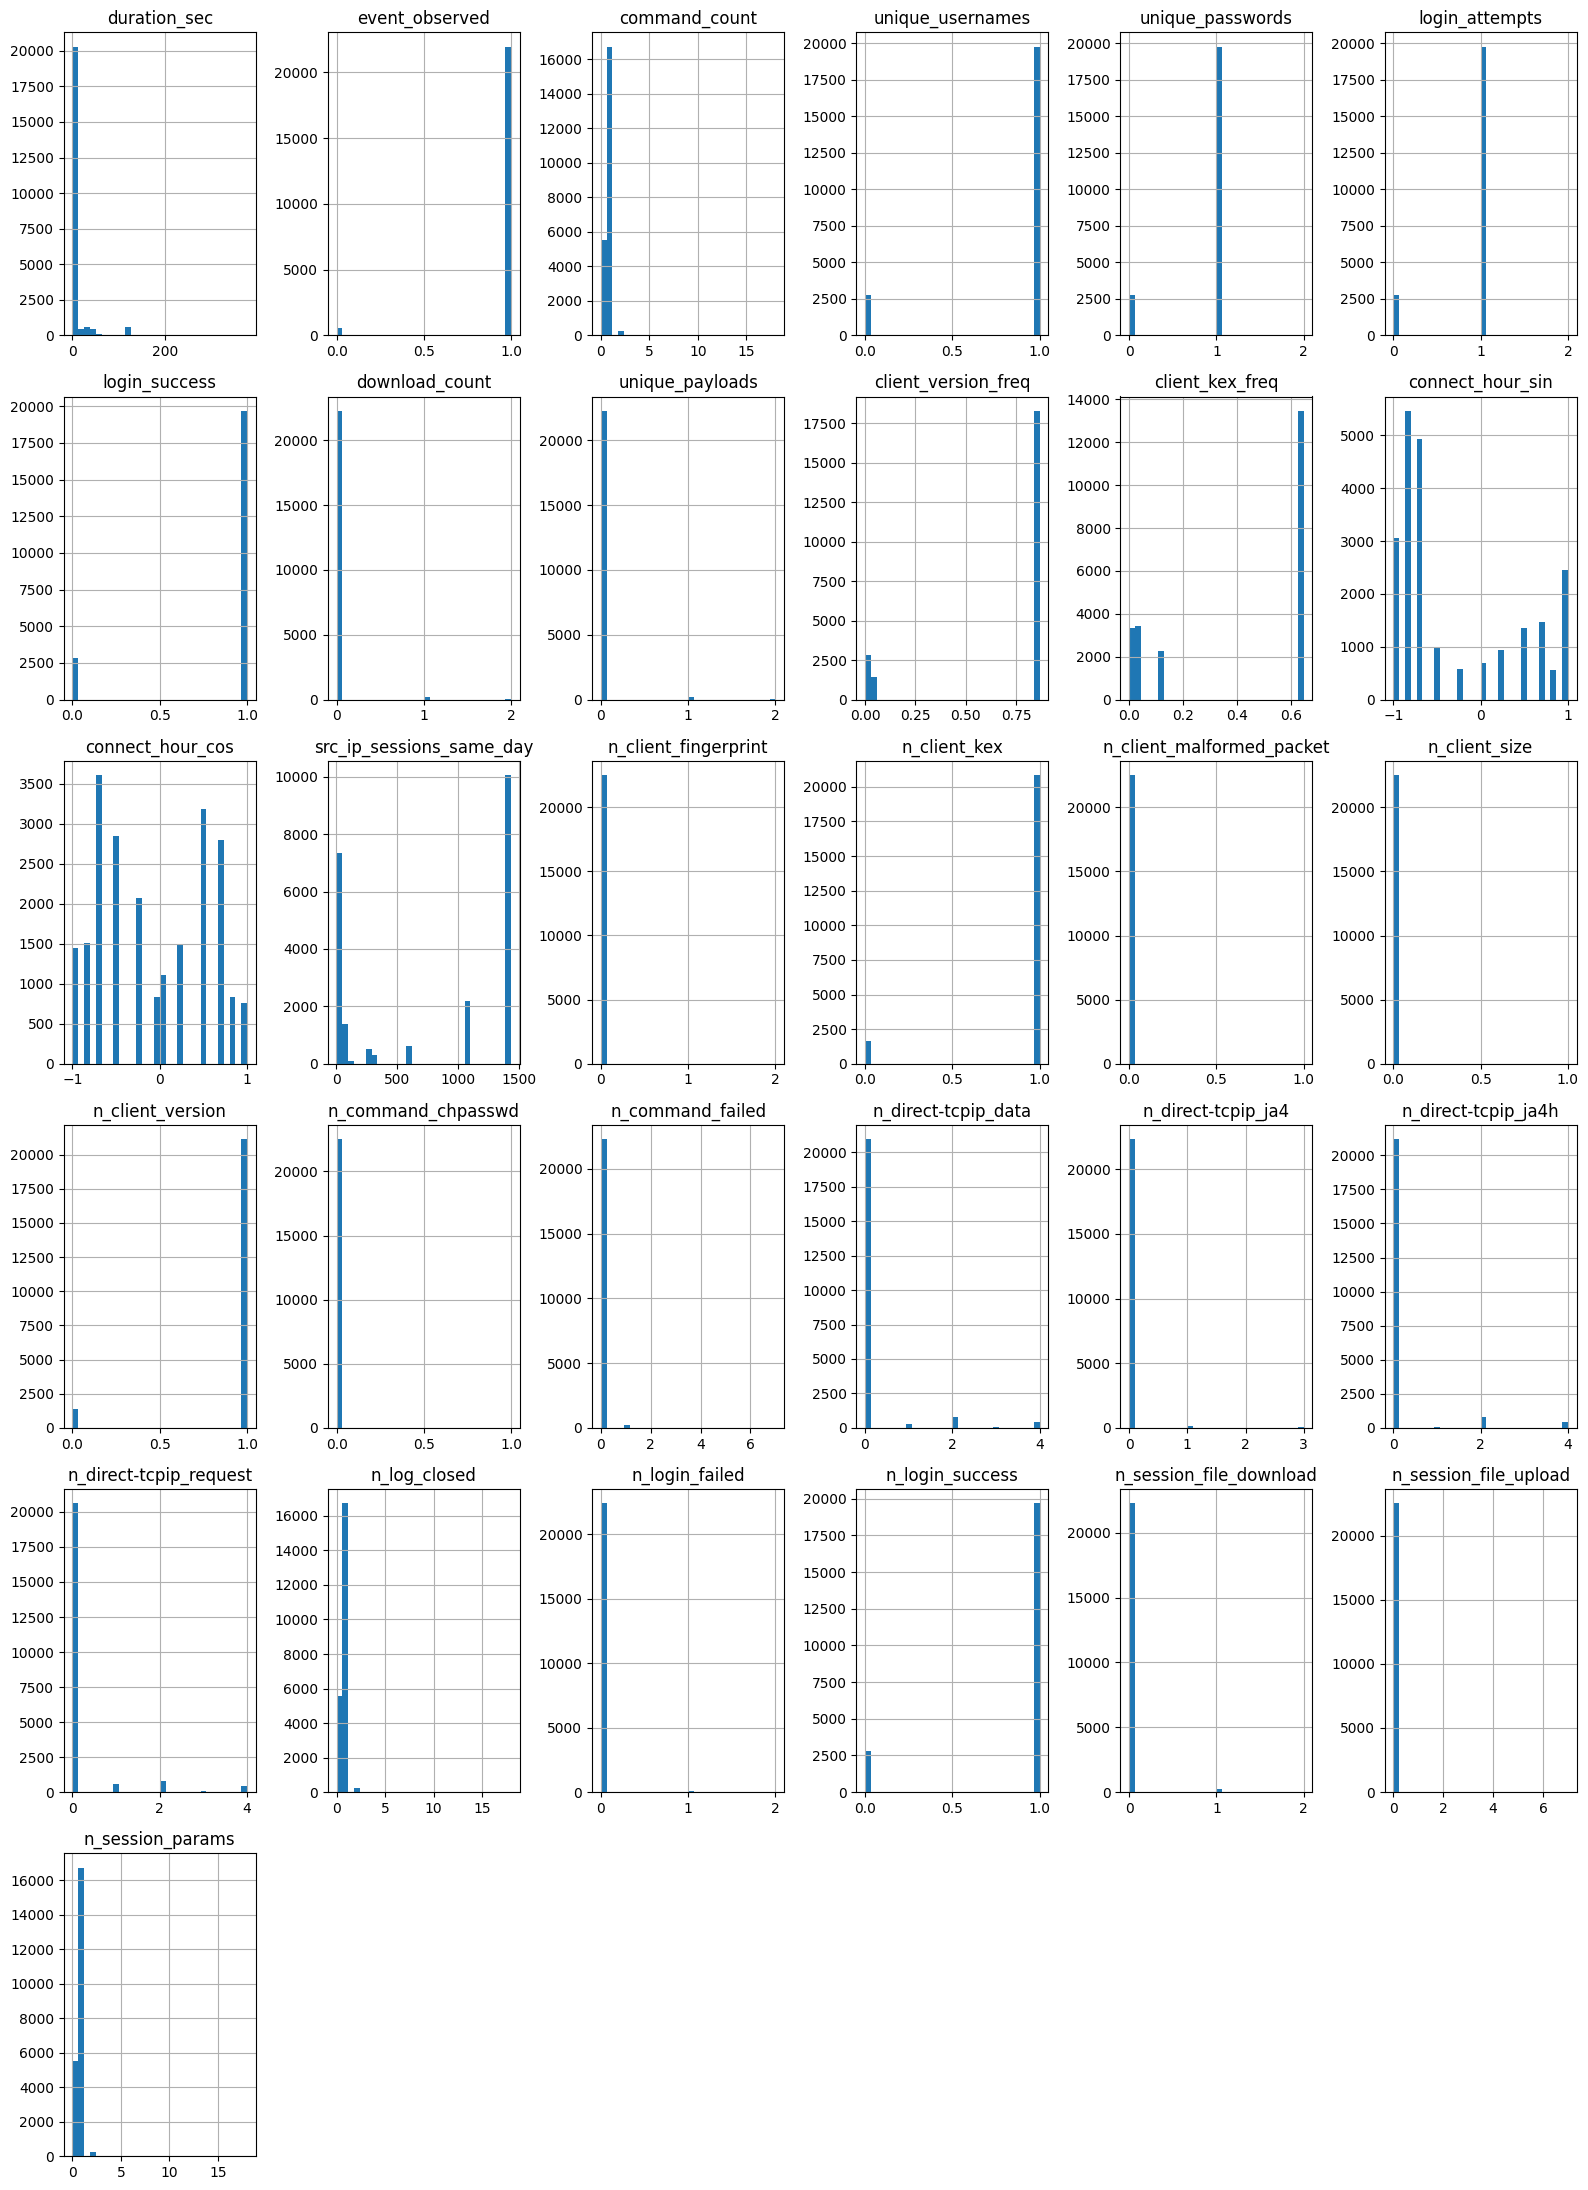

In [11]:
numeric = sessions.select_dtypes(include=["number", "bool"]).astype(float)
numeric.hist(figsize=(16, 22), bins=30)
plt.tight_layout()
plt.show()

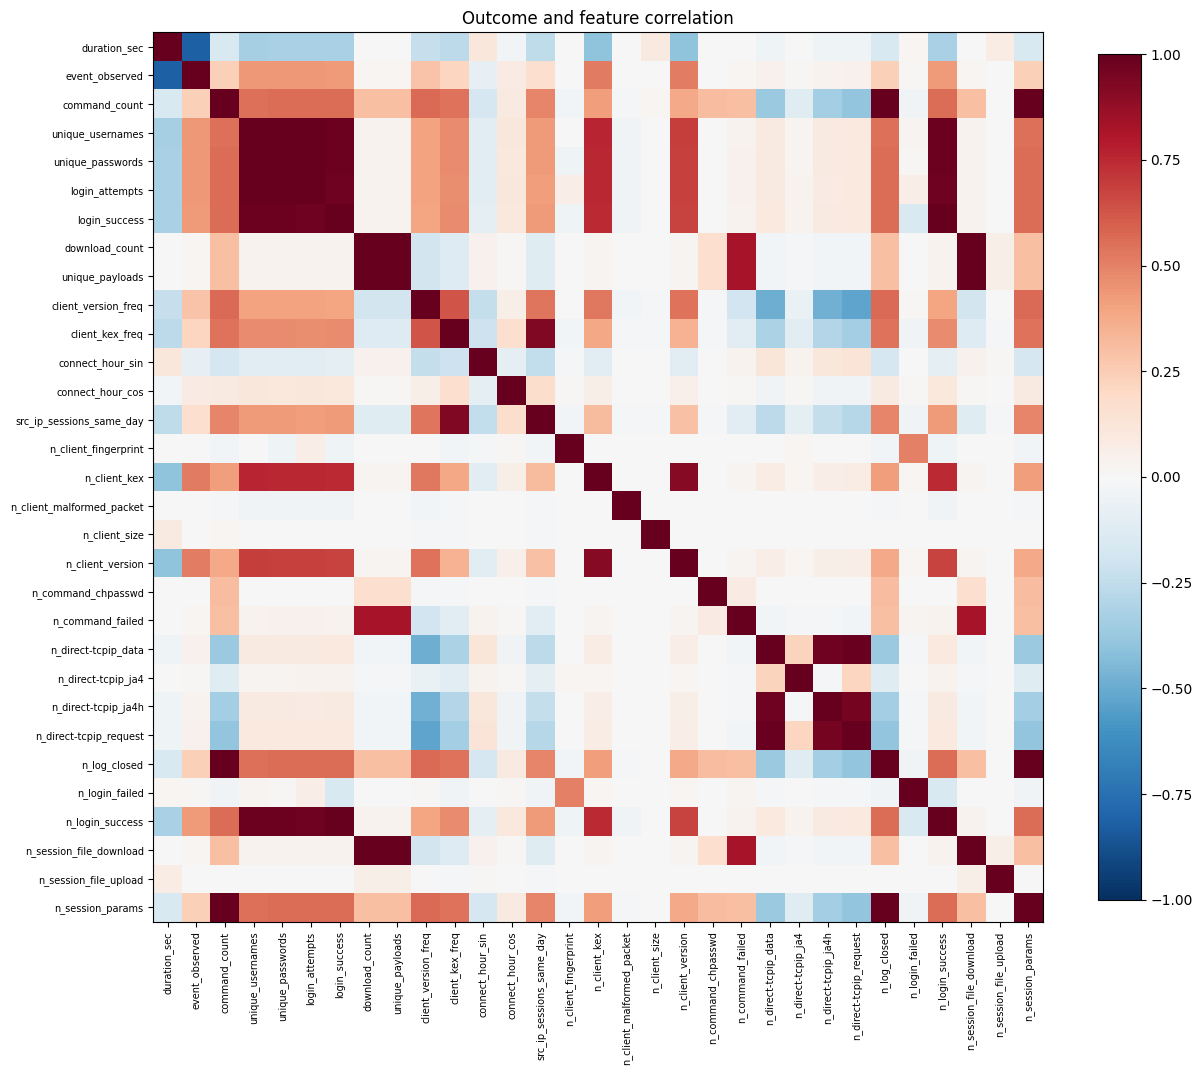

In [12]:
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(0.35 * len(corr.columns) + 2, 0.35 * len(corr.columns) + 2))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, shrink=0.7)
ax.set_title("Outcome and feature correlation")
fig.tight_layout()
plt.show()

## 9. Write out

In [13]:
from pathlib import Path

out_dir = Path("/data/work/sessions")
out_dir.mkdir(parents=True, exist_ok=True)
sessions.to_parquet(out_dir / "sessions.parquet", index=False)
print(f"wrote {len(sessions)} rows to {out_dir / 'sessions.parquet'}")

wrote 22511 rows to /data/work/sessions/sessions.parquet
